### PROJECT - CUSTOMER SPENDING SEGMENTATION

#### PROBLEM STATEMENT AND PROJECT OBJECTIVE
##### Retail companies treats all customers uniformly despite large differences in their revenue contribution and purchasing behavior, leading to inefficient allocation of marketing resources and increased revenue risk. The objective of this project is to identify customer segments that differ in both revenue contribution and revenue stability, enabling value-aware and risk-aware business strategies.

#### CONTENTS OF THIS NOTEBOOK
##### 1. Importing the required libraries and the dataset.
##### 2. Primary checks like duplicates, missing values, dtypes, shape of the dataset.
##### 3. Information about the features to be created.
##### 4. Checking correlation of the new features using heatmaps, outlier checks of the new columns using boxplots, and the data distribution checks using kdeplots and skewness values.
##### 5. Decision on how to handle outliers in the dataset and the next preprocessing steps.

In [ ]:
# Importing the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import skew
from sklearn.preprocessing import PowerTransformer, StandardScaler

In [130]:
# Importing the raw dataset

df = pd.read_csv("../data/raw/raw.csv")
df.head()

,product_id,user_id,order_id,delivered_at,sale_price
0,14159,18372,23073,2024-02-11 08:18:54+00:00,0.49
1,28700,9234,11503,2026-01-14 17:58:49.185918+00:00,1.50
2,28700,32315,40253,2025-08-03 02:25:14+00:00,1.50
3,14202,48716,60794,2023-06-04 18:46:57+00:00,1.50
4,28700,50721,63346,2025-09-29 19:13:41+00:00,1.50


In [131]:
# Checking if the dataset has duplicates

df.duplicated().sum()

np.int64(0)

In [132]:
# Checking if it has missing values
df.isnull().sum()

product_id      0
user_id         0
order_id        0
delivered_at    0
sale_price      0
dtype: int64

In [133]:
# Checking the datatypes of the columns of the dataset

df.dtypes

product_id        int64
user_id           int64
order_id          int64
delivered_at     object
sale_price      float64
dtype: object

In [134]:
# The column "delivered_at" is a date column, but the dtype is object here, so it has to be changed.

In [135]:
# Checking the number of unique values in each column of the dataset:

df.nunique()

product_id      23060
user_id         27586
order_id        31411
delivered_at    31405
sale_price       3702
dtype: int64

In [136]:
# Finding the shape of the dataset

df.shape

(45618, 5)

In [137]:
# There are 45618 rows in the dataset, but none of the columns in the dataset has 45618 unique values. Some values 
# are duplicated. So, this is an item-level data, not user-level data.

# Duplicates in user_id indicate that users may have placed multiple orders and/or purchased multiple items within the same order.
# There can be multiple items in a single order. So, duplicates in the order_id mean that some orders have multiple items.

# Duplicates in product_id mean that the same product/item has been ordered in many orders.
# The column "delivered_at" has 31405 unique values and the column "order_id" has 31411 unique values. This means
# that the "delivered_at" is an order-level data, and 6 orders have been delivered at the same date.

#### FEATURES TO BE CREATED:
##### We can create some important features from this dataset, Recency (how many days back did the customer made the last purchase), Frequency (how many times the customer had purchased from the company), Monetary (how much total money did the customer spend), average_order_value (amount of money spent by the customers per order), avg_items_per_order (the average number of items a customer buys per order), customer_lifespan_days(total number of days the customer has been shopping from the company), active_months (the number of months in which a customer has placed minimum one order), monetary_per_active_month (the average amount a customer spends per active month), frequency_per_active_month (the number of times the customer places orders per active month), inter_purchase_gap_mean (the average number of days between two consective orders per customer), and inter_purchase_gap_std (the consistency of the gaps per customer).

##### All the features have been created in the feature_engineering.py file.

##### Importing the dataset with the new features created:

In [141]:
rfm_df = pd.read_csv("../data/processed/rfm_features.csv")
rfm_df.head()

,user_id,monetary,frequency,last_purchase_date,recency,avg_items_per_order,average_order_value,first_purchase_date,last_purchase,customer_lifespan_days,active_months,monetary_per_active_month,frequency_per_active_month,inter_purchase_gap_mean,inter_purchase_gap_std
0,1,25.000000,1,2022-06-21 11:29:28+00:00,1290,1.0,25.000000,2022-06-21 11:29:28+00:00,2022-06-21 11:29:28+00:00,1,1,25.000000,1.0,0.0,0.0
1,7,38.000000,1,2025-05-28 07:13:09+00:00,218,2.0,38.000000,2025-05-28 07:13:09+00:00,2025-05-28 07:13:09+00:00,1,1,38.000000,1.0,0.0,0.0
2,12,55.299999,1,2021-04-06 18:52:43+00:00,1731,1.0,55.299999,2021-04-06 18:52:43+00:00,2021-04-06 18:52:43+00:00,1,1,55.299999,1.0,0.0,0.0
3,13,52.250000,1,2024-10-01 23:38:00+00:00,457,1.0,52.250000,2024-10-01 23:38:00+00:00,2024-10-01 23:38:00+00:00,1,1,52.250000,1.0,0.0,0.0
4,15,52.000000,1,2025-08-05 00:57:54+00:00,149,1.0,52.000000,2025-08-05 00:57:54+00:00,2025-08-05 00:57:54+00:00,1,1,52.000000,1.0,0.0,0.0


In [142]:
# Checking for missing values in the dataset

rfm_df.isnull().sum()

user_id                       0
monetary                      0
frequency                     0
last_purchase_date            0
recency                       0
avg_items_per_order           0
average_order_value           0
first_purchase_date           0
last_purchase                 0
customer_lifespan_days        0
active_months                 0
monetary_per_active_month     0
frequency_per_active_month    0
inter_purchase_gap_mean       0
inter_purchase_gap_std        0
dtype: int64

##### Now the new features need to be checked for correlation and outliers. All columns except user_id, last_purchase_date, first_purchase_date, last_purchase has to be checked for correlation.

In [143]:
cols = rfm_df.columns.to_list()
cols_to_check = cols.copy()

# The columns to check for correlation:
cols_to_check.remove("user_id")
cols_to_check.remove("first_purchase_date")
cols_to_check.remove("last_purchase_date")
cols_to_check.remove("last_purchase")

In [144]:
cols_to_check

['monetary',
 'frequency',
 'recency',
 'avg_items_per_order',
 'average_order_value',
 'customer_lifespan_days',
 'active_months',
 'monetary_per_active_month',
 'frequency_per_active_month',
 'inter_purchase_gap_mean',
 'inter_purchase_gap_std']

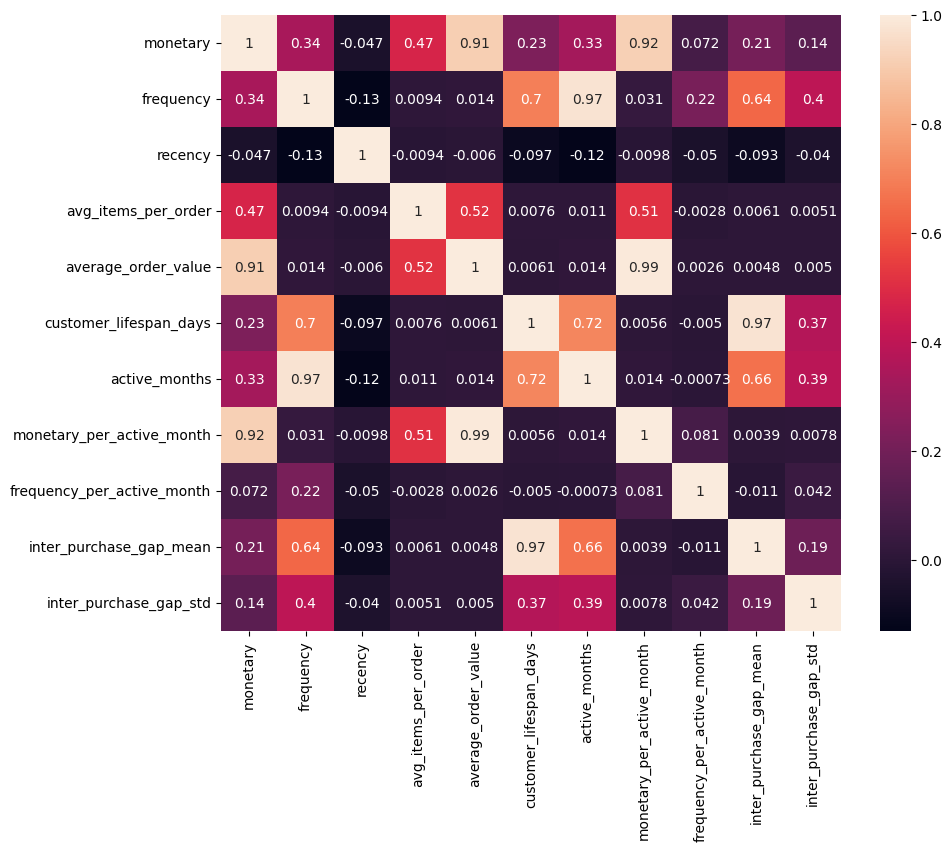

In [145]:
# Checking for correlation between the features:

plt.figure(figsize = (10, 8))
sns.heatmap(rfm_df[cols_to_check].corr(), annot = True)
plt.show()

#### Observations from the above heatmap:
##### Monetary is in high correlation with monetary_per_active_month, average_order_value.
##### Frequency is in high correlation with active_months. average_order_value is in high correlation with monetary_per_active_month. customer_lifespan_days is in high correlation with inter_purchase_gap_mean. 
##### So, the features monetary, frequency, average_order_value, customer_lifespan_days can be removed. We can also remove the feature recency, because we have other strong features like active_months, inter_purchase_gap, inter_purchase_mean.

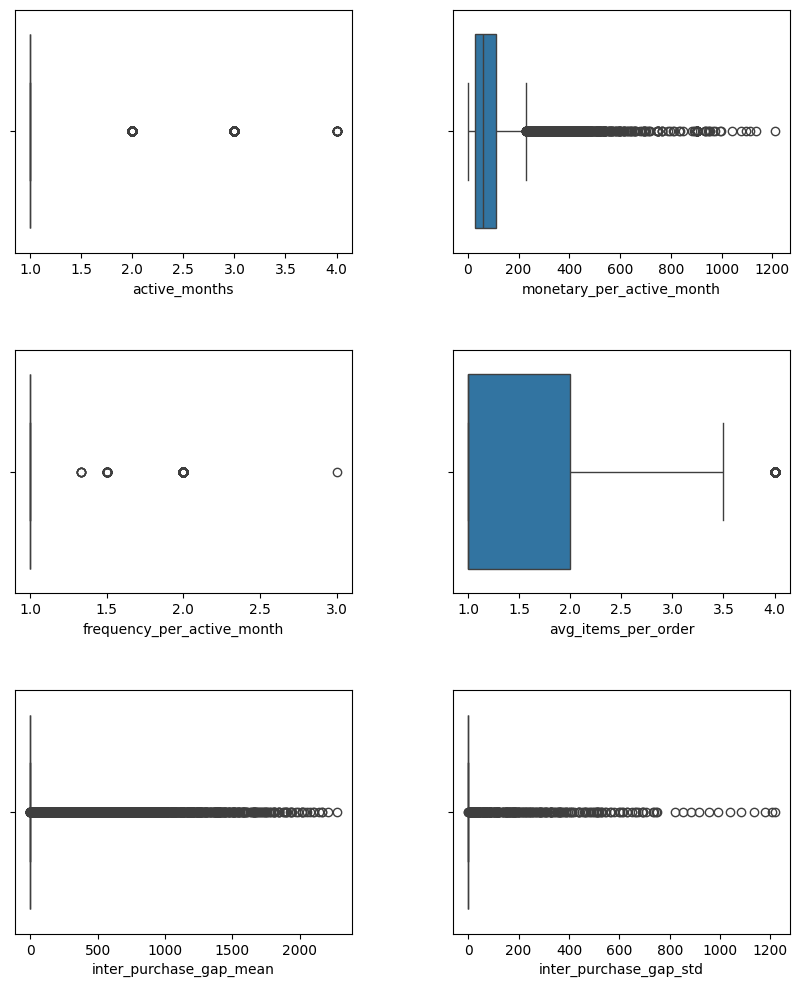

In [146]:
# Plotting boxplots to check for outliers in the features

outlier_check_cols = ["active_months", "monetary_per_active_month", "frequency_per_active_month", "avg_items_per_order",
                      "inter_purchase_gap_mean", "inter_purchase_gap_std"] # The columns to be checked for outliers

plt.close("all")
fig = plt.figure(figsize = (10, 12))
spec = fig.add_gridspec(3, 2)
spec.update(wspace = 0.3, hspace = 0.4)
sec_1 = fig.add_subplot(spec[0, 0])
sec_2 = fig.add_subplot(spec[0, 1])
sec_3 = fig.add_subplot(spec[1, 0])
sec_4 = fig.add_subplot(spec[1, 1])
sec_5 = fig.add_subplot(spec[2, 0])
sec_6 = fig.add_subplot(spec[2, 1])

sec = [sec_1, sec_2, sec_3, sec_4, sec_5, sec_6]
cnt = 0
for col in outlier_check_cols:
    sns.boxplot(x = col, ax = sec[cnt], data = rfm_df)
    cnt += 1
plt.show()

#### Observations from the above boxplots
##### There are outliers in all the features, but all of them seem to be valid. We need to further investigate about the outliers and skewness in each column.

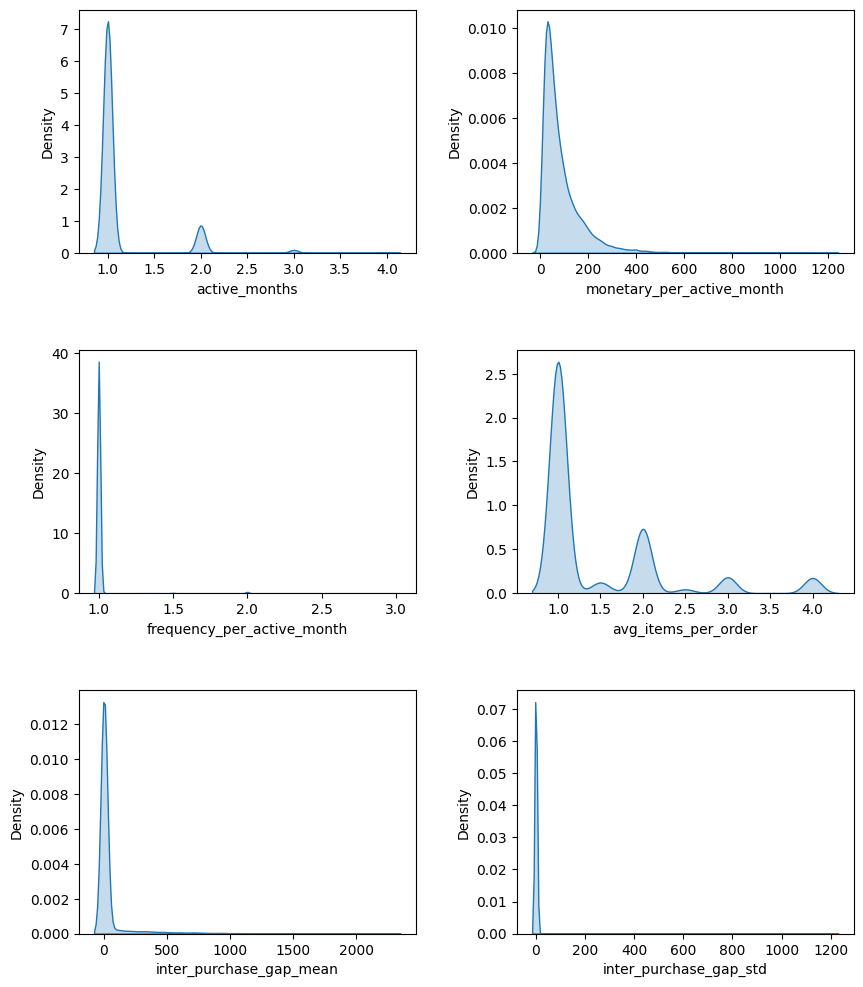

In [151]:
# Plotting kdeplots to find if the features are skewed or normally distributed:

fig = plt.figure(figsize = (10, 12))
spec = fig.add_gridspec(3, 2)
spec.update(wspace = 0.3, hspace = 0.4)
sec_1 = fig.add_subplot(spec[0, 0])
sec_2 = fig.add_subplot(spec[0, 1])
sec_3 = fig.add_subplot(spec[1, 0])
sec_4 = fig.add_subplot(spec[1, 1])
sec_5 = fig.add_subplot(spec[2, 0])
sec_6 = fig.add_subplot(spec[2, 1])

sec = [sec_1, sec_2, sec_3, sec_4, sec_5, sec_6]
cnt = 0
for col in outlier_check_cols:
    sns.kdeplot(x = col, ax = sec[cnt], data = rfm_df, fill = True)
    cnt += 1
plt.show()

#### Observations from the above kdeplots
##### All the features are skewed. The features "active_months" and "avg_items_per_order" have more than one mode.

In [ ]:
# Defining a function to find the outlier percentage, skewness, upper and lower limits etc.

def detect_outliers(outlier_check_cols):
    for col in outlier_check_cols:
        Q1 = rfm_df[col].quantile(0.25)
        Q3 = rfm_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        max_val = rfm_df[col].max()
        min_val = rfm_df[col].min()
        highest_limit = rfm_df[col].quantile(0.99)
        lowest_limit = rfm_df[col].quantile(0.01)
        outliers_percent = (rfm_df[(rfm_df[col] < lower_bound) | (rfm_df[col] > upper_bound)].shape[0]/rfm_df.shape[0])*100
        outlier_rows = rfm_df[(rfm_df[col] < lower_bound) | (rfm_df[col] > upper_bound)].shape[0]
        print(f"Outlier percentage of the column {col} is {outliers_percent} %.")
        print(f"Number of outlier rows in the column {col} is {outlier_rows}.")
        print(f"Minimum value is {min_val}.")
        print(f"Lower limit is {lower_bound}.")
        print(f"Maximum value is {max_val}.")
        print(f"Upper limit is {upper_bound}.")
        print(f"99th percentile value is {highest_limit}.")
        print(f"1st percentile value is {lowest_limit}.")
        print(f"The number of rows above the 99th percentile is {rfm_df[rfm_df[col] > highest_limit].shape[0]}.")
        print(f"The number of rows below the 1st percentile is {rfm_df[rfm_df[col] < lowest_limit].shape[0]}.")
        print(f"Skewness of the column is {skew(rfm_df[col])}.")
        print()
        print()

In [148]:
# Using the function detect_outliers() to check for outliers and skewness

detect_outliers(outlier_check_cols)

Outlier percentage of the column active_months is 11.610458216896987 %.
Number of outlier rows in the column active_months is 3033.
Minimum value is 1.
Lower limit is 1.0.
Maximum value is 4.
Upper limit is 1.0.
99th percentile value is 3.0.
1st percentile value is 1.0.
The number of rows above the 99th percentile is 18.
The number of rows below the 1st percentile is 0.
Skewness of the column is 3.0288434067185697.


Outlier percentage of the column monetary_per_active_month is 6.262680396585385 %.
Number of outlier rows in the column monetary_per_active_month is 1636.
Minimum value is 1.5.
Lower limit is -90.0.
Maximum value is 1208.969997406006.
Upper limit is 230.0.
99th percentile value is 429.0.
1st percentile value is 7.949999809265136.
The number of rows above the 99th percentile is 261.
The number of rows below the 1st percentile is 254.
Skewness of the column is 3.2743989254958943.


Outlier percentage of the column frequency_per_active_month is 0.731156452168587 %.
Number of 

In [149]:
rfm_df[outlier_check_cols].describe()

,active_months,monetary_per_active_month,frequency_per_active_month,avg_items_per_order,inter_purchase_gap_mean,inter_purchase_gap_std
count,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000,26123.000000
mean,1.128239,86.842543,1.006533,1.449470,51.261781,2.956491
std,0.370739,90.408110,0.078615,0.779432,199.948939,37.612636
min,1.000000,1.500000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,30.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,58.000000,1.000000,1.000000,0.000000,0.000000
75%,1.000000,110.000000,1.000000,2.000000,0.000000,0.000000
max,4.000000,1208.969997,3.000000,4.000000,2272.000000,1216.223664


#### Insights from the detect_outliers function and the statistical summary of the features:
##### There are outliers and skewness in all the features. But the outliers are valid values. There can be customers who are inactive for a long period or purchased frequently in a month. So, we cannot remove the outliers or cap them blindly. We have to transform the features using yeo-johnson transformation, since there are zeroes in inter_purchase_gap_mean and inter_purchase_gap_std.

#### The transformation and scaling has been done in the data_preprocessing.py file. Importing the proceesed dataset:

In [150]:
processed_df = pd.read_csv("../data/processed/processed_features.csv")
processed_df.head()

,avg_items_per_order,active_months,monetary_per_active_month,frequency_per_active_month,inter_purchase_gap_mean,inter_purchase_gap_std,user_id
0,-0.688255,-0.36243,-0.930419,0.0,-0.37184,-0.113976,1.0
1,1.382901,-0.36243,-0.471491,0.0,-0.37184,-0.113976,7.0
2,-0.688255,-0.36243,-0.057412,0.0,-0.37184,-0.113976,12.0
3,-0.688255,-0.36243,-0.120142,0.0,-0.37184,-0.113976,13.0
4,-0.688255,-0.36243,-0.125443,0.0,-0.37184,-0.113976,15.0
